In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    MobileNetV2, ResNet50, EfficientNetB0, InceptionV3
)
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Reshape, Dropout, Multiply, Add, Conv2D, MaxPooling2D, Layer, LSTM, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import Input

In [2]:
def get_data_generators(data_dir, img_size=(224, 224), batch_size=32):
    train_dir = "/content/drive/MyDrive/Colab Notebooks/Traffic Sign in BD/bd_traffic_signs/train"
    val_dir = "/content/drive/MyDrive/Colab Notebooks/Traffic Sign in BD/bd_traffic_signs/val"
    test_dir = "/content/drive/MyDrive/Colab Notebooks/Traffic Sign in BD/bd_traffic_signs/test"

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    test_val_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')

    val_gen = test_val_datagen.flow_from_directory(
        val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')

    test_gen = test_val_datagen.flow_from_directory(
        test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

    return train_gen, val_gen, test_gen

In [3]:
def build_hybrid_model(input_shape=(224, 224, 3), num_classes=13):
    inputs = Input(shape=input_shape)

    # --- CNN feature extractor ---
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)  # 112x112

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)  # 56x56

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)  # 28x28

    # --- Reshape CNN output to sequences for LSTM ---
    x = Reshape((28 * 28, 128))(x)  # Shape: (batch_size, timesteps, features)

    # --- LSTM for sequence modeling ---
    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(0.5)(x)

    # --- Fully connected classifier ---
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [4]:
def get_transfer_model(model_name, input_shape, num_classes):
    if model_name == 'mobilenet':
        base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    elif model_name == 'resnet':
        base_model = ResNet50(input_shape=input_shape, include_top=False, weights='imagenet')
    elif model_name == 'efficientnet':
        base_model = EfficientNetB0(input_shape=input_shape, include_top=False, weights='imagenet')
    elif model_name == 'inception':
        base_model = InceptionV3(input_shape=input_shape, include_top=False, weights='imagenet')
    else:
        raise ValueError("Unknown model name")

    base_model.trainable = False  # Freeze the base model

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [5]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/Traffic Sign in BD/bd_traffic_signs"
IMG_SHAPE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 13
MODELS = ['mobilenet', 'resnet', 'efficientnet', 'inception', 'hybrid']

# Output dir
os.makedirs("outputs", exist_ok=True)

train_gen, val_gen, test_gen = get_data_generators(DATA_DIR, IMG_SHAPE, BATCH_SIZE)
class_names = list(train_gen.class_indices.keys())

Found 5863 images belonging to 13 classes.
Found 1671 images belonging to 13 classes.
Found 852 images belonging to 13 classes.


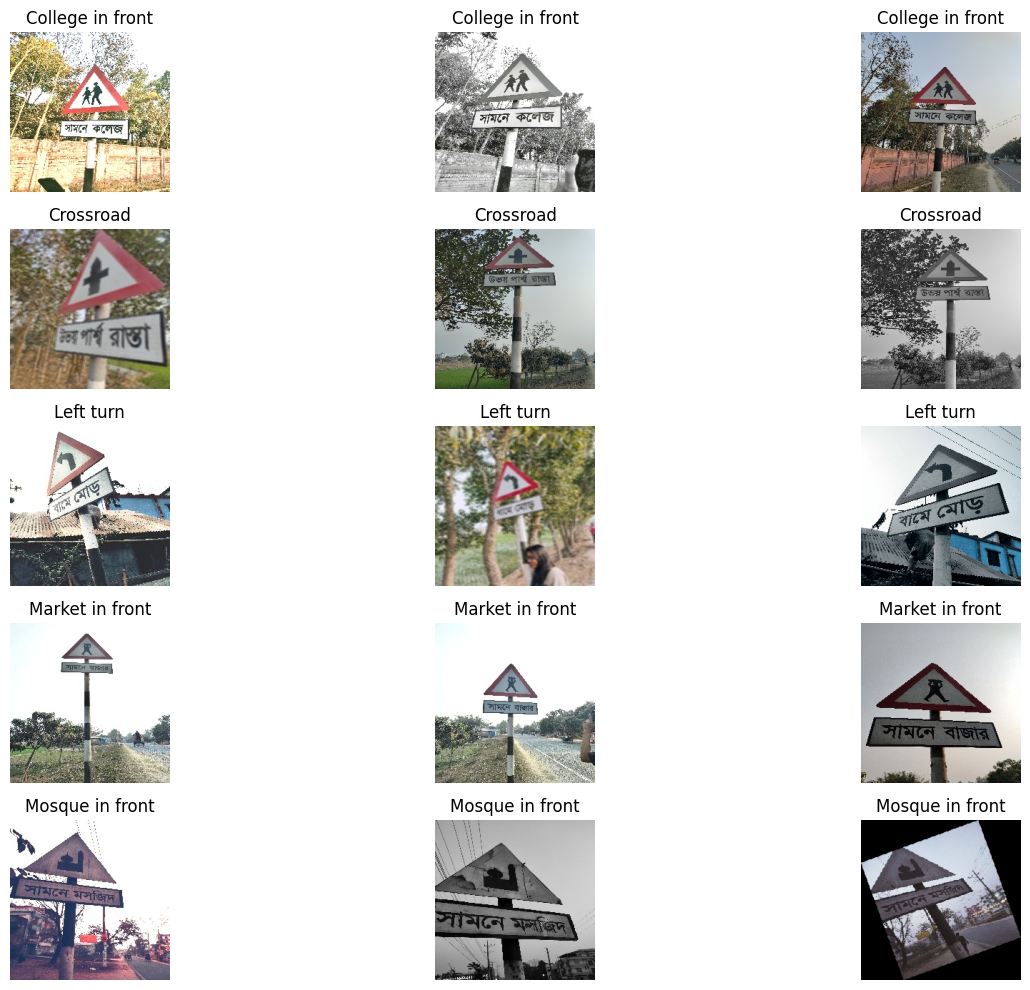

In [6]:
# Display some images from specific classes
def display_images_by_class(test_gen, class_names, num_images_per_class=3):
    """Displays a few images from each specified class."""
    class_indices = test_gen.class_indices
    inv_class_indices = {v: k for k, v in class_indices.items()}

    # Get image paths and labels from the test generator
    test_image_paths = test_gen.filepaths
    test_image_labels = test_gen.classes

    plt.figure(figsize=(15, 10))

    for class_name in class_names:
        class_idx = class_indices[class_name]
        # Find indices of images belonging to the current class
        class_image_indices = [i for i, label in enumerate(test_image_labels) if label == class_idx]

        # Select a few random images from the class
        selected_image_indices = np.random.choice(class_image_indices, min(num_images_per_class, len(class_image_indices)), replace=False)

        for i, img_idx in enumerate(selected_image_indices):
            img_path = test_image_paths[img_idx]
            img = tf.keras.utils.load_img(img_path, target_size=IMG_SHAPE)
            img_array = tf.keras.utils.img_to_array(img)

            plt.subplot(len(class_names), num_images_per_class, class_names.index(class_name) * num_images_per_class + i + 1)
            plt.imshow(img_array.astype('uint8'))
            plt.title(class_name)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Select some classes to display images from (e.g., the first 5 classes)
classes_to_display = class_names[:5]
display_images_by_class(test_gen, classes_to_display)

In [7]:
def plot_training(history, model_name):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.suptitle(model_name.upper())
    plt.tight_layout()
    plt.savefig(f"outputs/{model_name}_training.png")
    plt.close()

def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name.upper()} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"outputs/{model_name}_confusion_matrix.png")
    plt.close()

def plot_roc(y_true_bin, y_score, model_name):
    plt.figure(figsize=(10, 8))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC={roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name.upper()} ROC Curves")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"outputs/{model_name}_roc_curve.png")
    plt.close()

# Train & Evaluate Each Model
for model_name in MODELS:
    print(f"\n--- Training {model_name.upper()} ---")

    if model_name == "hybrid":
        model = build_hybrid_model(input_shape=IMG_SHAPE + (3,), num_classes=NUM_CLASSES)
    else:
        model = get_transfer_model(model_name, input_shape=IMG_SHAPE + (3,), num_classes=NUM_CLASSES)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS)

    plot_training(history, model_name)

    # Predictions
    y_true = test_gen.classes
    y_proba = model.predict(test_gen)
    y_pred = np.argmax(y_proba, axis=1)

    # Classification Report
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\nClassification Report for {model_name.upper()}:\n{report}")

    with open(f"outputs/{model_name}_report.txt", "w") as f:
        f.write(report)

    plot_conf_matrix(y_true, y_pred, model_name)

    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plot_roc(y_true_bin, y_proba, model_name)


--- Training MOBILENET ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1823s 10s/step - accuracy: 0.3322 - loss: 2.1264 - val_accuracy: 0.7499 - val_loss: 0.8791
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 73s 399ms/step - accuracy: 0.7134 - loss: 0.9003 - val_accuracy: 0.8288 - val_loss: 0.6197
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 74s 400ms/step - accuracy: 0.7988 - loss: 0.6685 - val_accuracy: 0.8648 - val_loss: 0.4939
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 73s 395ms/step - accuracy: 0.8143 - loss: 0.5897 - val_accuracy: 0.8893 - val_loss: 0.4220
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 73s 397ms/step - accuracy: 0.8465 - loss: 0.4850 - val_accuracy: 0.8995 - val_loss: 0.3857
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 73s 399ms/step - accuracy: 0.8659 - loss: 0.4386 - val_accuracy: 0.9054 - val_loss: 0.3509
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 73s 399ms/step - accuracy: 0.8779 - loss: 0.4281 - val_accuracy: 0.9114 - val_loss: 0.3380
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 73s 396ms/step - accuracy: 0.8758 - loss: 0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Training INCEPTION ---
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 106s 493ms/step - accuracy: 0.3231 - loss: 2.1707 - val_accuracy: 0.7355 - val_loss: 0.9087
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 74s 402ms/step - accuracy: 0.6648 - loss: 1.0242 - val_accuracy: 0.8169 - val_loss: 0.6478
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 75s 408ms/step - accuracy: 0.7453 - loss: 0.8089 - val_accuracy: 0.8378 - val_loss: 0.5284
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 76s 413ms/step - accuracy: 0.7879 - loss: 0.6595 - val_accuracy: 0.8444 - val_loss: 0.4971
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 76s 415ms/step - accuracy: 0.8010 - loss: 0.6167 - val_accuracy: 0.8671 - val_loss: 0.4251
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 76s 415ms/step - accuracy: 0.8125 - loss: 0.5608 - val_accuracy: 0.8761 - val_loss: 0.4083
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 77s 418ms/step - accuracy: 0.8281 - loss: 0.5299 - val_accuracy: 0.8941 - val_loss: 0.3676
Epo

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
